In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
df['Fuel_Type'].unique(), df['Selling_type'].unique(), df['Transmission'].unique()

(<StringArray>
 ['Petrol', 'Diesel', 'CNG']
 Length: 3, dtype: str,
 <StringArray>
 ['Dealer', 'Individual']
 Length: 2, dtype: str,
 <StringArray>
 ['Manual', 'Automatic']
 Length: 2, dtype: str)

In [8]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

In [9]:
df['Car_Name'].nunique()

98

In [10]:
df['Car_Name'].value_counts().head(20)

Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
innova                        9
i20                           9
grand i10                     8
Royal Enfield Classic 350     7
amaze                         7
jazz                          7
sx4                           6
ertiga                        6
eon                           6
swift                         5
alto k10                      5
i10                           5
ritz                          4
wagon r                       4
Name: count, dtype: int64

In [11]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [13]:
pd.get_dummies(df[['Fuel_Type','Selling_type','Transmission']])

,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,False,False,True,True,False,False,True
1,False,True,False,True,False,False,True
2,False,False,True,True,False,False,True
3,False,False,True,True,False,False,True
4,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...
296,False,True,False,True,False,False,True
297,False,False,True,True,False,False,True
298,False,False,True,True,False,False,True
299,False,True,False,True,False,False,True


In [14]:
df_encoded = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

In [15]:
df_encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True


In [16]:
df_encoded.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Selling_type_Individual', 'Transmission_Manual'],
      dtype='str')

In [17]:
df_encoded = df_encoded.drop('Car_Name', axis=1)

In [18]:

X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

print(X.shape)
print(y.shape)

(301, 8)
(301,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 8)
(61, 8)
(240,)
(61,)


In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757]


In [25]:
print(y_pred[:10])

print(y_test[:10].values)

[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757]
[ 0.35 10.11  4.95  0.15  6.95  7.45  1.1   0.5   0.45  6.  ]


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)

0.8488707839193779


In [27]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

1.216374019333027


In [32]:
print(X.columns)

Index(['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='str')


In [33]:
new_car = pd.DataFrame(
    [[2020, 10, 20000, 0, 0, 1, 1, 1]],
    columns=X.columns
)

predicted_price = model.predict(new_car)

print(predicted_price)

[6.79681652]


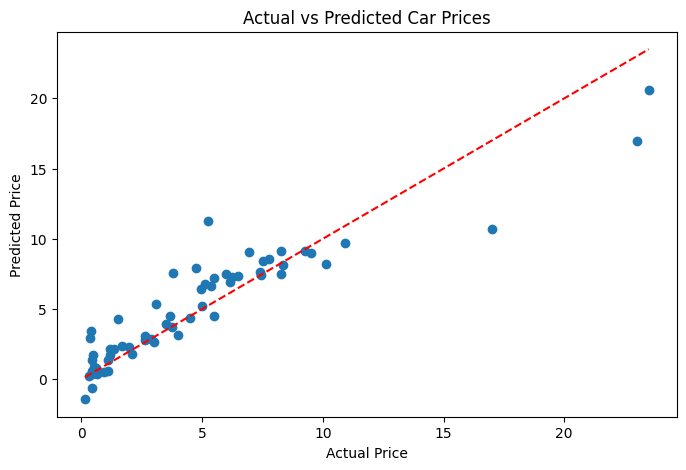

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

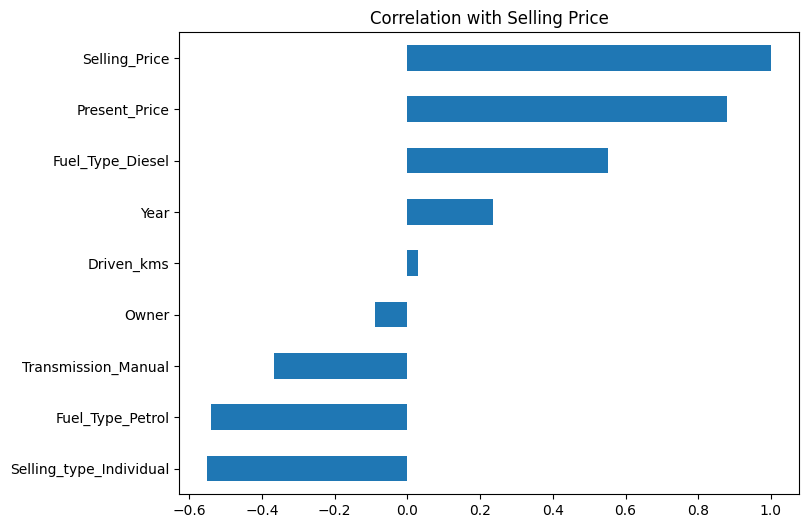

In [37]:
import matplotlib.pyplot as plt

corr = df_encoded.corr()

corr['Selling_Price'].sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Correlation with Selling Price")
plt.show()

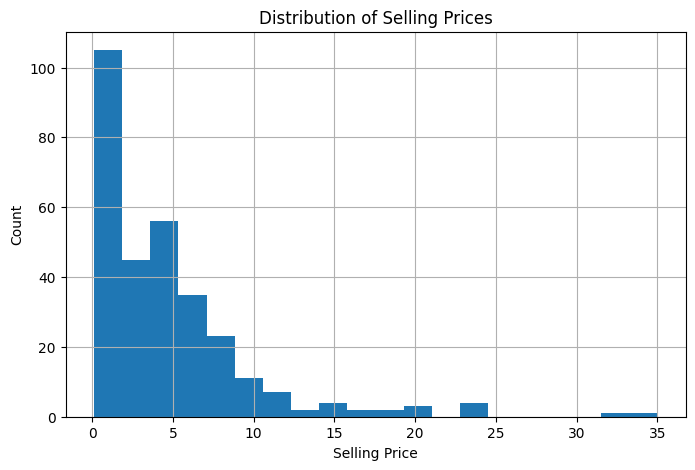

In [38]:
plt.figure(figsize=(8,5))

df['Selling_Price'].hist(bins=20)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.show()

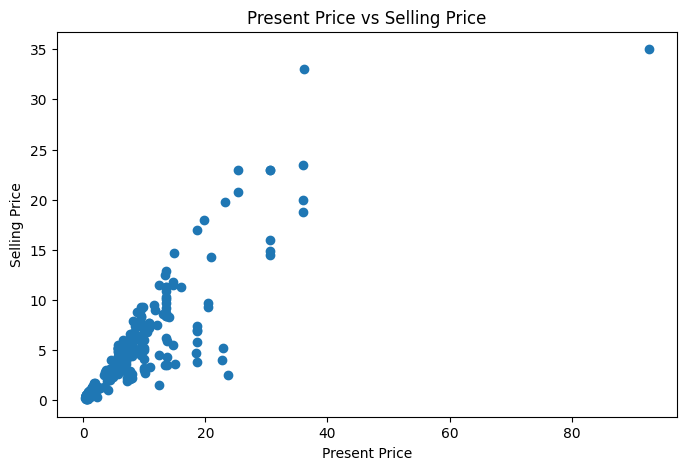

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Present_Price'],
    df['Selling_Price']
)

plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.title("Present Price vs Selling Price")

plt.show()